# PROC CAUSALMED로 금융 교육 프로그램이 대출 연체에 미치는 효과 분해하기

## 요약

한 소매 은행이 일부 대출자를 **금융 교육 프로그램**에 참여시키고, 프로그램에 등록한 대출자가 *왜* 덜 연체하는지를 알고자 합니다. 등록이 연체를 **직접적으로** 낮추는 것일까요, 아니면 측정 가능한 행동, 즉 고객이 소득 중 얼마를 저축하는지를 변화시켜 **간접적으로** 작용하는 것일까요? 이 노트북은 **PROC CAUSALMED**를 사용하여 프로그램이 12개월 연체에 미치는 총효과를 **자연 직접효과**와 각 대출자의 **저축률**을 통해 흐르는 **자연 간접효과**로 나누며, 신용점수, 소득, 나이를 보정합니다.

**대출자 100명**으로 구성된 시뮬레이션 코호트에서 이 프로그램은 모형화된 연체 확률을 **0.208**만큼 낮춥니다(위험차 척도에서의 총효과). 이 분해는 그중 **0.176(84.7%)**을 더 높은 저축을 통한 *간접* 경로에, 나머지 **0.032(15.3%)**만을 *직접* 경로에 귀속시킵니다. 실무적 시사점은 이렇습니다. 이 프로그램은 **주로 저축 행동을 개선함으로써** 대출자를 보호하므로, 예산 관리 습관을 강화하는 것이 지렛대가 되는 지점입니다.

## 데이터 출처

| 데이터셋 | 행 수 | 설명 | 주요 변수 |
|---------|------|-------------|---------------|
| `LoanProgram` | 합성 대출자 100명 | 하나의 대출 포트폴리오를 위해 인라인으로 생성한 소매 금융 코호트. 처치 배정, 매개변수, 결과는 명시적인 구조방정식으로부터 시뮬레이션되어, 절차가 복원할 수 있는 실제 매개 효과가 존재합니다. | `CustomerID`, `Branch`(4개 수준), `FinEdu`(0/1 금융 교육 등록 = 처치), `SavingsRate`(저축한 소득 비율 % = 연속형 매개변수), `Default`(0/1 12개월 대출 연체 = 이진 결과), `CreditScore`, `Income`, `Age`(교란변수) |

이 환경은 라이선스 없이 실행되므로 DATA 스텝은 100개 관측치로 제한됩니다. 코호트는 그 한도에 맞춰 크기가 정해졌으며, 이 노트북의 모든 수치는 이 100개 행에서 나옵니다.

## 왜 효과를 분해하는가?

소매 대출기관은 연체를 줄이기 위해 신용 상품에 **금융 교육 프로그램**을 점점 더 결합하고 있습니다. 자본 계획과 프로그램 설계를 위해서는 등록이 연체를 낮춘다는 사실을 아는 것만으로는 충분하지 않으며, 위험 담당자는 그 **메커니즘**을 필요로 합니다.

- 등록이 연체를 *직접적으로* 낮추는가(예: 등록한 대출자가 더 적극적으로 참여하고 연락이 잘 되는가)?
- 아니면 측정 가능한 행동, 즉 고객이 소득 중 저축하는 비율을 변화시키고 이것이 충격을 완화해줌으로써 *간접적으로* 작용하는가?

**인과 매개 분석**은 처치의 **총효과(TE)**를 **자연 직접효과(NDE)**와 선택한 매개변수를 통해 흐르는 **자연 간접효과(NIE)**로 나누어 이 질문에 답합니다. 여기서는 다음과 같습니다.

- **처치** `FinEdu` — 대출자가 은행의 금융 교육 프로그램에 등록했는지 여부;
- **매개변수** `SavingsRate` — 대출자의 저축률(소득 대비 %), 프로그램이 겨냥하는 행동;
- **결과** `Default` — 12개월 이내에 대출이 연체되었는지 여부(이진);
- **교란변수** `CreditScore`, `Income`, `Age` — 등록, 저축, 연체에 영향을 미치는 처치 이전 특성.

우리는 `PROC CAUSALMED`로 매개 모형을 적합하고, `DECOMP`로 직접/간접 분해를 요청한 뒤, 보호 효과 중 저축을 통해 흐르는 비율을 읽어냅니다.

In [1]:
데이터 LoanProgram;
   호출 streaminit(20260531);
   길이 Branch $12;
   배열 branches[4] $12 _temporary_ ('북부' '남부' '동부' '서부');
   반복 CustomerID = 1 까지 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* 처치 이전 교란변수 (먼저 생성) */
      CreditScore = round(620 + 70*rand('normal'), 1);
      만약 CreditScore < 350 이면 CreditScore = 350;
      만약 CreditScore > 850 이면 CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      만약 Income < 12000 이면 Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      만약 AGE < 21 이면 AGE = 21;

      /* 처치: 등록 성향은 신용점수와 소득이 높을수록 상승
         (단순 비교가 놓치는 교란) */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* 매개변수: 저축률. 교란변수 기반 기저값 위에
         프로그램이 추가로 끌어올림 */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      만약 SavingsRate < 0 이면 SavingsRate = 0;

      /* 결과: 연체 확률은 등록(직접효과)과 저축 증가
         (간접효과) 모두에 따라 감소 */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      만약 pDefault < 0.02 이면 pDefault = 0.02;
      만약 pDefault > 0.98 이면 pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      출력;
   종료;
   라벨 FinEdu='금융교육 이수' Default='대출 연체'
        SavingsRate='저축률' CreditScore='신용점수'
        Income='소득' AGE='연령' Branch='지점'
        CustomerID='고객ID';
   유지 CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
실행;


NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2단계 — 시뮬레이션 코호트 살펴보기

인과 모형을 적합하기 전에, 각 등록 그룹의 평균 저축률과 연체율을 점검합니다. 이는 *단순한*(보정하지 않은) 비교이며, 뒤이어 진행되는 매개 분석은 이를 넘어 그 차이를 직접 경로와 매개 경로로 귀속시킵니다.

In [2]:
처리 평균 데이터=LoanProgram n mean std maxdec=3;
   분류 FinEdu;
   변수 SavingsRate Default CreditScore Income AGE;
실행;

                                                  The MEANS Procedure

                                       Analysis Variable : SavingsRate 저축률

        금융교육 이수                      N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        0                               54          8.387          2.910
        1                               46         11.736          2.974
        ----------------------------------------------------------------

                                       Analysis Variable : Default 대출 연체

        금융교육 이수                      N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        0                               54          0.593          0.496
        1                               46          0.348          0.482
        ----------------------------------------------------------------

                                      Analysis 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


단순 비교의 그림은 명확합니다. 등록한 대출자(`FinEdu=1`, 46명)는 저축을 뚜렷하게 더 많이 하고(평균 **SavingsRate 11.74%**로, 등록하지 않은 54명의 **8.39%** 대비) 덜 자주 연체합니다(평균 **Default 0.348**로 **0.593** 대비, 원자료 기준 24.5%포인트 격차). 두 그룹은 평균 신용점수가 거의 동일하지만(619.8 대 618.9) 등록한 대출자의 소득이 다소 높은데(43,941 대 37,019), 이는 바로 인과 모형이 보정으로 제거해야 하는 종류의 교란입니다. 아래 교차표는 동일한 구분을 셀 빈도로 보여줍니다.

                                                   The FREQ Procedure

Table of 금융교육 이수 by 대출 연체

금융교육 이수             |         0 |         1 |      Total
--------------------+-----------+-----------+-----------
0                   |        22 |        32 |         54
--------------------+-----------+-----------+-----------
1                   |        30 |        16 |         46
--------------------+-----------+-----------+-----------
Total               |        52 |        48 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


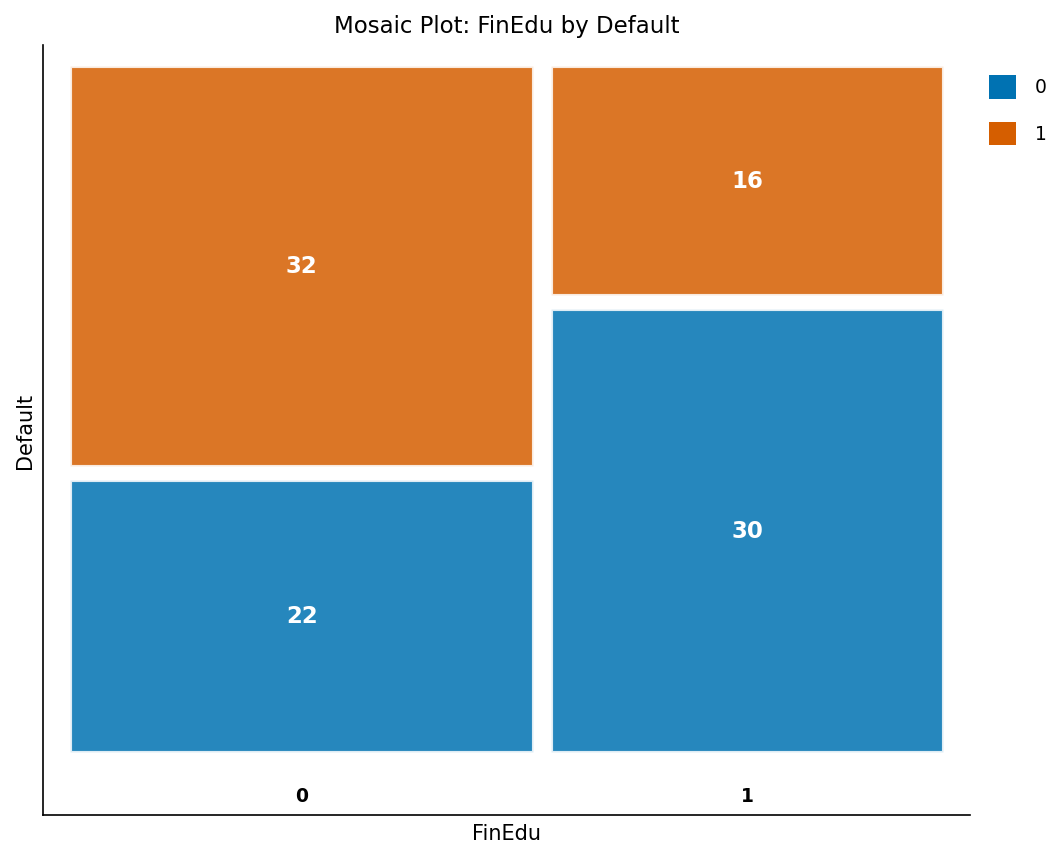

In [3]:
처리 빈도 데이터=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
실행;

등록하지 않은 대출자 54명 중 **32명이 연체**했고, 등록한 46명 중에서는 **16명만** 연체했습니다. 모자이크 플롯은 이를 한 번에 두 가지 방식으로 나타냅니다. 열의 너비는 각 그룹에 속한 대출자 수를 반영하고, 각 열 안의 주황색 비중은 연체율입니다. 오른쪽 등록 그룹에서 눈에 띄게 작습니다. 이제 매개 분석은 그 낮은 연체율 중 **얼마만큼**이 방금 확인한 더 높은 저축을 *통해* 작용하는 프로그램의 효과인지를 묻습니다.

## 3단계 — 인과 매개 분석 실행

`PROC CAUSALMED`를 적합합니다. 핵심 문장은 다음과 같습니다.

- **`CLASS FinEdu Default / descending`**은 처치와 이진 결과를 분류 변수로 선언합니다. `DESCENDING`은 더 높은 코드 수준(`1` = 등록/연체)을 모형화 대상 사건으로 만들어, 효과가 직관적인 방향으로 읽히게 합니다.
- **`MEDIATOR SavingsRate = FinEdu`**는 매개변수 모형을 지정합니다. 저축률을 처치(그리고 교란변수)에 회귀합니다.
- **`MODEL Default = FinEdu SavingsRate`**는 결과 모형을 지정합니다. 등록과 저축의 함수로서의 연체입니다. 이 라이선스 없는 엔진에서 CAUSALMED는 결과를 **선형(선형확률) 모형**으로 적합하므로, 효과는 **위험차** 척도로 보고되며 오즈비와 위험비 요약이 함께 도출됩니다.
- **`COVAR CreditScore Income Age`**는 두 모형 모두를 처치 이전 교란변수에 대해 보정합니다.
- **`DECOMP`**는 총효과를 직접 성분과 간접 성분, 그리고 매개된 비율로 분해할 것을 요청합니다.

결과가 이진이므로 CAUSALMED는 *이진 결과 요약(Summary for Binary Outcome)* 블록(오즈비, 위험비, 위험차)도 보고합니다.

In [4]:
처리 causalmed 데이터=LoanProgram decomp;
   분류    FinEdu Default / DESCENDING;
   mediator SavingsRate = FinEdu;
   모형    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
실행;


                       The CAUSALMED Procedure                       

Outcome Variable    : 대출 연체
Treatment Variable  : 금융교육 이수
Mediator Variable   : 저축률
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : 신용점수, 소득, 연령
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
금융교육 이수                              -0.031682
저축률                                  -0.067687
신용점수                                 -0.000719
소득                                    0.000002
연령                                   -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.585613
금융교육 이수                               2.597720
신용점수                                  0.024079
소득                                    0.000115



NOTE: PROC CAUSALMED data=LoanProgram



## 결과 해석

**인과 효과 요약(Summary of Causal Effects)** 표는 프로그램이 **연체에 미치는 총효과(TE) -0.208**을 보고하고 이를 다음과 같이 나눕니다.

- **자연 직접효과(NDE) -0.032** — 저축을 통하지 *않는* 보호의 부분, 그리고
- **자연 간접효과(NIE) -0.176** — 프로그램이 대출자의 저축률을 끌어올림으로써 흐르는 부분.

세 효과 모두 음수로, 등록이 연체 확률을 낮춤을 확인해 줍니다. 이는 우리가 데이터를 구성한 방식과 일치합니다. 두 모형 표는 *그 이유*를 보여줍니다. **매개변수 모형**에서 프로그램은 보정 후 저축률을 **+2.60점** 높이고(`FINEDU` 계수), **결과 모형**에서 저축이 1점 늘어날 때마다 연체 확률이 낮아지므로(`SAVINGSRATE` = -0.068), 프로그램의 저축 증대가 상당한 간접 보호 효과로 이어집니다.

**효과 분해(Decomposition of Effects)** 표는 핵심 결론을 명확히 합니다. **매개된 비율(NIE/TE)이 84.7%**이고, 효과 중 직접적인 부분은 **15.3%**에 불과합니다. 위험 팀에게 이는 실행 가능한 시사점입니다. 금융 교육 프로그램은 **대부분 저축 행동을 변화시킴으로써** 작동하므로, 예산 관리와 자동 저축 기능을 강화하는 것이 우선순위가 되어야 합니다. 직접 비중이 작다는 점은 다른 경로(참여, 연락 가능성)가 여기서는 거의 기여하지 않음을 시사합니다.

**이진 결과 요약(Summary for Binary Outcome)** 블록은 신용 위험 팀이 이미 사용하는 척도로 효과를 다시 표현합니다. **위험차 -0.208**(TE), **위험비 1.43**, 그리고 등록 그룹과 비등록 그룹의 연체 오즈를 연결하는 **오즈비 2.38**입니다. 이 엔진에서 이들은 적합된 로지스틱 모형이 아니라 선형확률 효과로부터 도출된 1차 요약이므로, **위험차가 주된 정확한 효과 척도**이고 비율 요약은 근사값으로 읽는 것이 가장 좋습니다.

**주의:** 인과 매개 추정치는 처치–결과 관계와 매개변수–결과 관계 모두에 대한 미측정 교란 부재 가정만큼만 신뢰할 수 있습니다. 여기서는 그 가정이 구성상 성립합니다(합성 데이터). 실무에서는 위험 팀이 분해에 근거해 행동하기 전에 은행의 전체 신청자 특성 집합과 민감도 분석으로 이를 뒷받침할 것입니다. 또한 추정치는 단일한 100명 표본을 반영하므로, 실제 연구라면 확고한 결론을 내리기 전에 신뢰구간을 붙일 것입니다(예: 분해를 부트스트랩하여).